In [3]:
"""
Mutual Fund Analytics Capstone Project

Notebook: 05_advanced_analytics.ipynb

Purpose:
Performs advanced risk analysis by calculating metrics such as Maximum Drawdown,
Tracking Error, Value at Risk (VaR), Conditional Value at Risk (CVaR), and
other analytical indicators for mutual fund evaluation.

Author: Yash Ridla
Date: June 2026
"""

'\nMutual Fund Analytics Capstone Project\n\nNotebook: 05_advanced_analytics.ipynb\n\nPurpose:\nPerforms advanced risk analysis by calculating metrics such as Maximum Drawdown,\nTracking Error, Value at Risk (VaR), Conditional Value at Risk (CVaR), and\nother analytical indicators for mutual fund evaluation.\n\nAuthor: Yash Ridla\nDate: June 2026\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# TASK 1

In [5]:
import pandas as pd
import numpy as np

# Load cleaned NAV data
nav_df = pd.read_csv("../Data/Processed/clean_nav.csv")

# Date conversion and sorting
nav_df["date"] = pd.to_datetime(nav_df["date"])
nav_df = nav_df.sort_values(["amfi_code", "date"])

# Daily returns
nav_df["daily_return"] = nav_df.groupby("amfi_code")["nav"].pct_change()

# Remove NaN values
returns_df = nav_df.dropna(subset=["daily_return"])

# VaR and CVaR calculation
results = []

for fund, group in returns_df.groupby("amfi_code"):

    var_95 = np.percentile(group["daily_return"], 5)

    cvar_95 = group.loc[
        group["daily_return"] <= var_95,
        "daily_return"
    ].mean()

    results.append([
        fund,
        round(var_95, 6),
        round(cvar_95, 6)
    ])

var_cvar_report = pd.DataFrame(
    results,
    columns=["amfi_code", "VaR_95", "CVaR_95"]
)

display(var_cvar_report.head())

# Save report
var_cvar_report.to_csv(
    "../Data/Processed/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved successfully")

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


var_cvar_report.csv saved successfully


# TASK 2

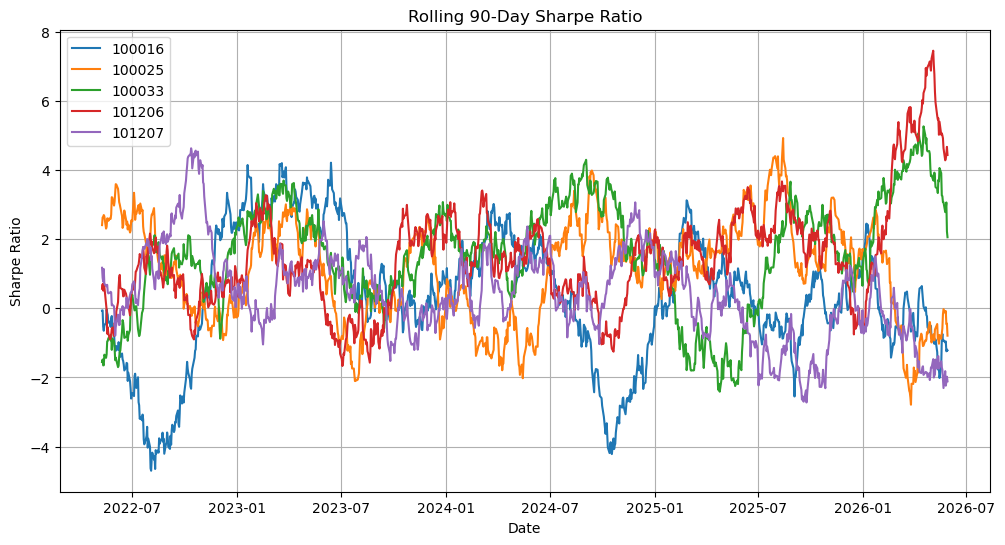

rolling_sharpe_chart.png saved successfully


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load NAV data
nav_df = pd.read_csv("../Data/Processed/clean_nav.csv")

nav_df["date"] = pd.to_datetime(nav_df["date"])
nav_df = nav_df.sort_values(["amfi_code", "date"])

# Daily returns
nav_df["daily_return"] = nav_df.groupby("amfi_code")["nav"].pct_change()

# Top 5 funds
top_funds = nav_df["amfi_code"].drop_duplicates().head(5)

plt.figure(figsize=(12,6))

for fund in top_funds:

    temp = nav_df[nav_df["amfi_code"] == fund].copy()

    rolling_sharpe = (
        temp["daily_return"].rolling(90).mean()
        /
        temp["daily_return"].rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig(
    "../Reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

plt.show()

print("rolling_sharpe_chart.png saved successfully")

# TASK 3

In [10]:
import pandas as pd

txn = pd.read_csv("../Data/Processed/clean_transactions.csv")

# Date convert
txn["transaction_date"] = pd.to_datetime(txn["transaction_date"])

# First transaction year per investor
first_txn = (
    txn.groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = first_txn["transaction_date"].dt.year

# Add cohort back
txn = txn.merge(
    first_txn[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

# Average SIP amount
avg_sip = (
    txn[txn["transaction_type"] == "SIP"]
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="avg_sip_amount")
)

# Total invested amount
total_invested = (
    txn.groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested")
)

# Preferred fund (most frequent AMFI code)
fund_pref = (
    txn.groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="count")
)

fund_pref = (
    fund_pref.sort_values(
        ["cohort_year", "count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

fund_pref = fund_pref[
    ["cohort_year", "amfi_code"]
].rename(
    columns={"amfi_code": "preferred_fund"}
)

# Final cohort report
cohort_analysis = (
    avg_sip
    .merge(total_invested, on="cohort_year")
    .merge(fund_pref, on="cohort_year")
)

display(cohort_analysis)

# Save
cohort_analysis.to_csv(
    "../Data/Processed/cohort_analysis.csv",
    index=False
)

print("cohort_analysis.csv saved successfully")

,cohort_year,avg_sip_amount,total_invested,preferred_fund
0,2024,10996.885825,3491125187,148568
1,2025,13505.209581,30455243,119599


cohort_analysis.csv saved successfully


# TASK 4

In [ ]:
import pandas as pd

txn = pd.read_csv("../Data/Processed/clean_transactions.csv")

txn["transaction_date"] = pd.to_datetime(txn["transaction_date"])

# Only SIP transactions
sip_txn = txn[txn["transaction_type"] == "SIP"].copy()

# Investors with 6+ SIP transactions
eligible_investors = (
    sip_txn.groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible_investors = eligible_investors[
    eligible_investors["sip_count"] >= 6
]

sip_txn = sip_txn.merge(
    eligible_investors[["investor_id"]],
    on="investor_id",
    how="inner"
)

# Sort transactions
sip_txn = sip_txn.sort_values(
    ["investor_id", "transaction_date"]
)

# Gap between transactions
sip_txn["gap_days"] = (
    sip_txn.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

# Average gap
sip_continuity = (
    sip_txn.groupby("investor_id")["gap_days"]
    .mean()
    .reset_index(name="avg_gap_days")
)

# Risk flag
sip_continuity["status"] = sip_continuity[
    "avg_gap_days"
].apply(
    lambda x: "at-risk" if x > 35 else "active"
)

display(sip_continuity.head())

# Save deliverable
sip_continuity.to_csv(
    "../Data/Processed/sip_continuity.csv",
    index=False 
)

print("sip_continuity.csv saved successfully")

,investor_id,avg_gap_days,status
0,INV000004,85.400000,at-risk
1,INV000008,70.400000,at-risk
2,INV000010,64.800000,at-risk
3,INV000011,40.166667,at-risk
4,INV000012,57.000000,at-risk


sip_continuity.csv saved successfully


# TASK 5

In [13]:
import pandas as pd

scorecard = pd.read_csv("../Data/Processed/fund_scorecard.csv")

scorecard["risk_grade"] = pd.qcut(
    scorecard["score"],
    q=3,
    labels=["Low", "Moderate", "High"]
)

display(
    scorecard[
        ["scheme_name", "score", "risk_grade", "sharpe_ratio"]
    ].head()
)

,scheme_name,score,risk_grade,sharpe_ratio
0,ICICI Pru Midcap Fund - Regular - Growth,9.00,Low,1.180101
1,Kotak Flexicap Fund - Regular - Growth,9.40,Low,1.306744
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,10.50,Low,1.093699
3,SBI Small Cap Fund - Regular Plan - Growth,10.75,Low,0.945308
4,Mirae Asset Large Cap Fund - Regular - Growth,11.00,Low,1.448291


In [14]:
risk_appetite = "Moderate"   # Low / Moderate / High

recommendations = (
    scorecard[scorecard["risk_grade"] == risk_appetite]
    .sort_values("sharpe_ratio", ascending=False)
    [["amfi_code", "scheme_name", "risk_grade", "sharpe_ratio", "score"]]
    .head(3)
)

print(f"Top 3 recommendations for {risk_appetite} risk investors:\n")

display(recommendations)

Top 3 recommendations for Moderate risk investors:



,amfi_code,scheme_name,risk_grade,sharpe_ratio,score
14,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,Moderate,0.926287,18.125
25,102885,UTI Nifty 50 Index Fund - Regular - Growth,Moderate,0.817099,22.600
23,120503,ICICI Pru Bluechip Fund - Regular - Growth,Moderate,0.797973,21.950


In [16]:
recommender_code = '''
import pandas as pd

scorecard = pd.read_csv("../Data/Processed/fund_scorecard.csv")

scorecard["risk_grade"] = pd.qcut(
    scorecard["score"],
    q=3,
    labels=["Low", "Moderate", "High"]
)

risk_appetite = input("Enter Risk Appetite (Low/Moderate/High): ")

recommendations = (
    scorecard[scorecard["risk_grade"] == risk_appetite]
    .sort_values("sharpe_ratio", ascending=False)
    [["amfi_code","scheme_name","risk_grade","sharpe_ratio","score"]]
    .head(3)
)

print("\\nTop 3 Recommended Funds:\\n")
print(recommendations.to_string(index=False))
'''

with open("../Scripts/recommender.py", "w") as f:
    f.write(recommender_code)

print("recommender.py created successfully")

recommender.py created successfully


# TASK 6

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

holdings = pd.read_csv("../Data/Raw/09_portfolio_holdings.csv")

# HHI Calculation
sector_hhi = (
    holdings.groupby("amfi_code")
    .apply(lambda x: np.sum((x["weight_pct"])**2))
    .reset_index(name="HHI")
)

# Classification
sector_hhi["portfolio_type"] = np.where(
    sector_hhi["HHI"] > 1500,
    "Concentrated",
    "Diversified"
)

display(sector_hhi.head())

# Save CSV
sector_hhi.to_csv(
    "../Data/Processed/sector_hhi.csv",
    index=False
)

print("sector_hhi.csv saved successfully")

C:\Users\user\AppData\Local\Temp\ipykernel_21520\1953280396.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.sum((x["weight_pct"])**2))


,amfi_code,HHI,portfolio_type
0,100016,1395.3386,Diversified
1,100033,1475.9226,Diversified
2,101206,1293.3173,Diversified
3,101207,2007.0043,Concentrated
4,102885,1747.0902,Concentrated


sector_hhi.csv saved successfully


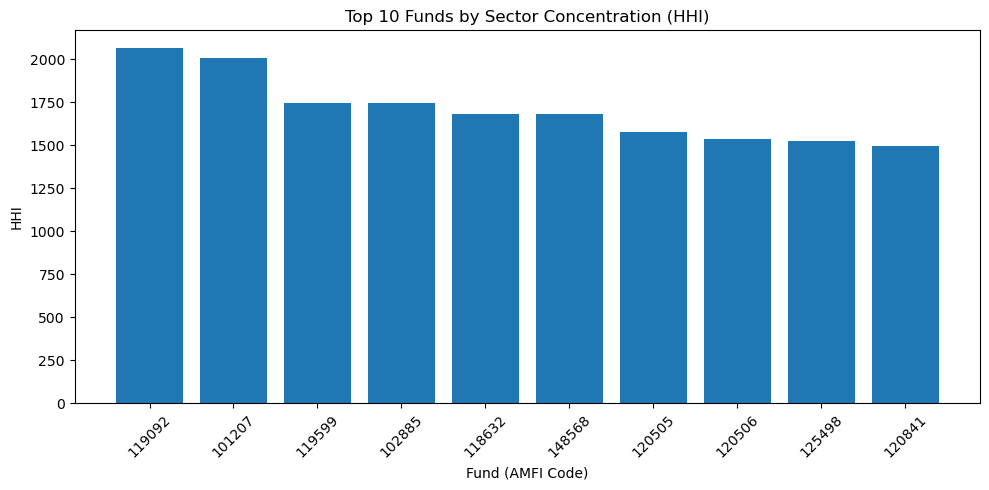

sector_hhi.png saved successfully


In [19]:
import matplotlib.pyplot as plt

top10 = sector_hhi.sort_values(
    "HHI",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["HHI"]
)

plt.title("Top 10 Funds by Sector Concentration (HHI)")
plt.xlabel("Fund (AMFI Code)")
plt.ylabel("HHI")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../Reports/sector_hhi.png",
    bbox_inches="tight"
)

plt.show()

print("sector_hhi.png saved successfully")

# Advanced Analytics Summary – Key Insights

## 1. Downside Risk Analysis (VaR & CVaR)

The Value at Risk (VaR 95%) and Conditional Value at Risk (CVaR 95%) analysis revealed significant variation in downside risk across mutual funds. Funds with more negative VaR and CVaR values exhibited higher potential losses during adverse market conditions, indicating greater risk exposure.

## 2. Rolling Sharpe Ratio Performance

The 90-day rolling Sharpe Ratio analysis showed that risk-adjusted performance fluctuated over time for all selected funds. Certain funds consistently maintained higher Sharpe Ratios, suggesting superior returns relative to the level of risk undertaken.

## 3. Investor Cohort Behaviour

Investor cohort analysis indicated that the 2024 cohort contributed the highest overall investment amount, while the 2025 cohort demonstrated a higher average SIP contribution. This highlights changing investment behaviour among newer investors.

## 4. SIP Continuation and At-Risk Investors

By analysing investors with at least six SIP transactions, several investors were identified as "at-risk" due to average transaction gaps exceeding 35 days. These investors may require targeted engagement strategies to improve SIP continuity and retention.

## 5. Sector Concentration Risk (HHI)

The Herfindahl-Hirschman Index (HHI) analysis showed that some equity funds had highly concentrated sector allocations, while others maintained diversified exposure. Funds with higher HHI values are more vulnerable to sector-specific market downturns and therefore carry greater concentration risk.
